In [2]:
import pandas as pd
import numpy as np

In [3]:
crop = pd.read_csv("Crop_recommendation.csv")
crop.dropna(inplace=True)

In [4]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
crop.shape

(2199, 8)

In [6]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2199 entries, 0 to 2200
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2199 non-null   float64
 1   P            2199 non-null   float64
 2   K            2199 non-null   float64
 3   temperature  2199 non-null   float64
 4   humidity     2199 non-null   float64
 5   ph           2199 non-null   float64
 6   rainfall     2199 non-null   float64
 7   label        2199 non-null   object 
dtypes: float64(7), object(1)
memory usage: 154.6+ KB


In [7]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
crop.duplicated().sum()

np.int64(0)

In [9]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000
mean,50.545248,53.359709,48.160982,25.616357,71.481307,6.469418,103.461632
std,36.924444,32.993082,50.656379,5.064898,22.268865,0.774108,54.970807
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.768393,60.255364,5.971573,64.544549
50%,37.000000,51.000000,32.000000,25.600337,80.474764,6.424671,94.781896
75%,84.500000,68.000000,49.000000,28.561810,89.960531,6.923776,124.308842
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [10]:
crop.label.value_counts()

label
rice           100
chickpea       100
pigeonpeas     100
kidneybeans    100
mothbeans      100
mungbean       100
muskmelon      100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
coconut        100
apple          100
orange         100
papaya         100
jute           100
cotton         100
coffee         100
maize           99
Name: count, dtype: int64

In [11]:
crop['label'].unique().size

22

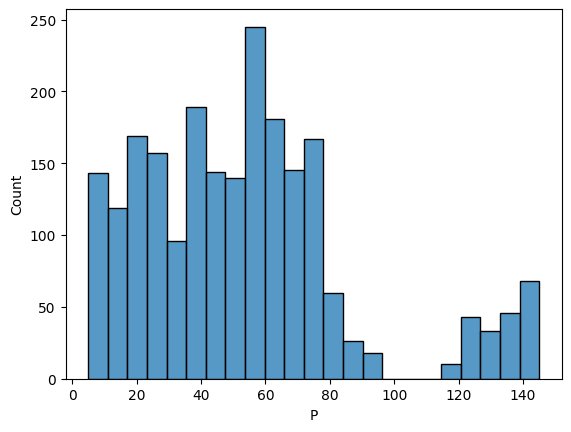

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(crop['P'])
plt.show()

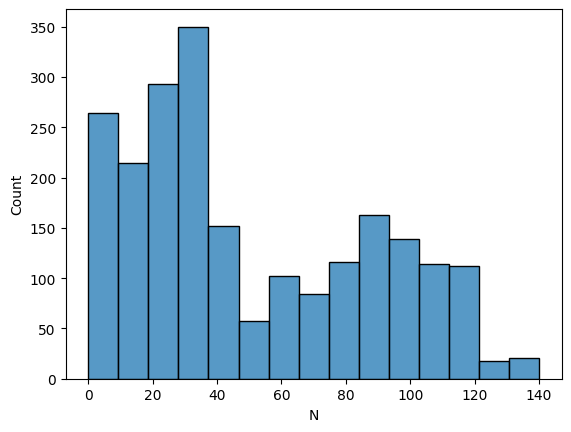

In [13]:
import matplotlib.pyplot as plt
sns.histplot(crop['N'])
plt.show()

In [14]:
crop.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

Encoding

In [15]:
crop_dict={
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}

if crop['label'].dtype == 'object':
    crop['label'] = crop['label'].map(crop_dict)


In [16]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,1
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,1
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,1
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,1
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,1


In [17]:
crop.label.unique()

array([ 1,  2, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,
        6,  5,  4,  3, 22])

In [18]:
crop.label.value_counts()

label
1     100
21    100
19    100
20    100
18    100
17    100
9     100
16    100
15    100
14    100
13    100
12    100
11    100
10    100
5     100
8     100
7     100
6     100
3     100
4     100
22    100
2      99
Name: count, dtype: int64

In [19]:
X=crop.drop('label', axis = 1)
y=crop['label']

In [20]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340


In [21]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64

Train Test Split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [23]:
X_train.shape

(1759, 7)

In [24]:
from sklearn.preprocessing import MinMaxScaler
mx = MinMaxScaler()
X_train_temp, X_test_temp, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
X_train = mx.fit_transform(X_train_temp)
X_test = mx.transform(X_test_temp)

In [25]:
X_train

array([[0.05      , 0.48571429, 0.1       , ..., 0.57013446, 0.58835229,
        0.08980509],
       [0.        , 0.45714286, 0.08      , ..., 0.55556509, 0.5548963 ,
        0.059176  ],
       [0.        , 0.08571429, 0.125     , ..., 0.39328927, 0.43145185,
        0.27871305],
       ...,
       [0.23571429, 0.17142857, 0.145     , ..., 0.40781249, 0.51758197,
        0.26149246],
       [0.16428571, 0.95      , 0.975     , ..., 0.76954416, 0.38265891,
        0.1732242 ],
       [0.13571429, 0.52857143, 0.07      , ..., 0.62414946, 0.49336599,
        0.08149422]], shape=(1759, 7))

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [27]:
models = {
    'LogisticRegression': LogisticRegression(),
    'GaussianNB':GaussianNB(),
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'ExtraTreeClassifier':ExtraTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'BaggingClassifier':BaggingClassifier(),
    'GradientBoostingClassifier':GradientBoostingClassifier(),
    'AdaBoostClassifier':AdaBoostClassifier()
}

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"{name} model with accuracy: {score}")

LogisticRegression model with accuracy: 0.9409090909090909
GaussianNB model with accuracy: 0.9931818181818182
SVC model with accuracy: 0.9772727272727273
KNeighborsClassifier model with accuracy: 0.9681818181818181
DecisionTreeClassifier model with accuracy: 0.9863636363636363
ExtraTreeClassifier model with accuracy: 0.9022727272727272
RandomForestClassifier model with accuracy: 0.990909090909091
BaggingClassifier model with accuracy: 0.9863636363636363
GradientBoostingClassifier model with accuracy: 0.9863636363636363
AdaBoostClassifier model with accuracy: 0.17954545454545454


In [29]:
randclf = RandomForestClassifier()
randclf.fit(X_train, y_train)
y_pred = randclf.predict(X_test)
accuracy_score(y_test, y_pred)

0.990909090909091

In [30]:
crop.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [31]:
def recommendation(N,P,K,temperature,humidity,ph,rainfall):
    features = pd.DataFrame([[N,P,K,temperature,humidity,ph,rainfall]], columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])
    mx_features = mx.transform(features)
    prediction = randclf.predict(mx_features).reshape(1,-1)
    return prediction[0]

In [32]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,1
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,1
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,1
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,1
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,1


In [33]:
N=90
P= 42
K= 43
temperature= 20.879744
humidity=82.002744
ph=6.502985
rainfall=202.935536

predict = recommendation(N,P,K,temperature,humidity,ph,rainfall)

In [34]:
predict

array([1])

In [35]:
import pickle
pickle.dump(randclf, open('model.pkl', 'wb'))
pickle.dump(mx, open('minmaxscaler.pkl', 'wb'))